# Compute Delay Spread at each Array

## Imports

In [1]:
from dataset_RT import training_set
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

2026-02-09 12:57:27.631117: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770641847.653407    6236 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770641847.660166    6236 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770641847.678228    6236 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770641847.678246    6236 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770641847.678248    6236 computation_placer.cc:177] computation placer alr

## Load Dataset and Compute Delay Spreads

In [2]:
def csi_time_domain(csi, pos):
    csi = tf.signal.fftshift(tf.signal.ifft(tf.signal.fftshift(csi, axes = -1)), axes=-1)
    
    return csi, pos

def cut_out_taps(tap_start):
    def cut_out_taps_func(csi, pos):
        return csi[...,tap_start:], pos
    
    return cut_out_taps_func

def csi_to_delayspreads(csi, pos):
    # csi comes in as shape (arrays, rows, columns, subcarriers)
    # --> we want (arrays, antennas = rows * columns, subcarriers), reshape!
    csi_by_array = tf.reshape(csi, (tf.shape(csi)[0], tf.shape(csi)[1]*tf.shape(csi)[2], tf.shape(csi)[3]))
    print(csi_by_array)
    powers = tf.square(tf.abs(csi_by_array))
    timestamps = tf.range(tf.shape(csi_by_array)[2], dtype = np.float32) / 50e6 # BW = 50e6
    time_weighted_powers = tf.einsum("amt,t->amt", powers, timestamps)
    mean_delays = tf.divide(tf.reduce_sum(time_weighted_powers, axis = 2), tf.reduce_sum(powers, axis = 2))
    squared_delays = tf.square(timestamps[tf.newaxis, tf.newaxis, :] - mean_delays[:, :, tf.newaxis])
    delayspreads = tf.sqrt(tf.divide(tf.reduce_sum(tf.multiply(squared_delays, powers), axis = 2), tf.reduce_sum(powers, axis = 2)))

    return csi, delayspreads, pos

training_set = training_set.map(csi_time_domain, num_parallel_calls = tf.data.AUTOTUNE)
training_set = training_set.map(cut_out_taps(32-8), num_parallel_calls = tf.data.AUTOTUNE)
training_set_with_ds = training_set.map(csi_to_delayspreads, num_parallel_calls = tf.data.AUTOTUNE)

Tensor("Reshape:0", shape=(8, 64, 40), dtype=complex64)


### From TensorFlow to NumPy

In [3]:
groundtruth_positions = []
delayspreads = []

for csi, ds, pos in training_set_with_ds.batch(1000):
    groundtruth_positions.append(pos.numpy())
    delayspreads.append(ds.numpy())

groundtruth_positions = np.concatenate(groundtruth_positions)
delayspreads = np.concatenate(delayspreads)

2026-02-09 12:57:31.347156: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:381] TFRecordDataset `buffer_size` is unspecified, default to 262144
2026-02-09 12:57:35.876242: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Delay Spreads per Array

In [4]:
# average delay spreads per array
delayspreads_by_array = np.mean(delayspreads, axis = -1)
np.save("results/delayspreads.npy", delayspreads_by_array)

## Visualize Delay Spreads

In [5]:
# load RX positions
array_positions = np.load("dataset/array_positions.npy")

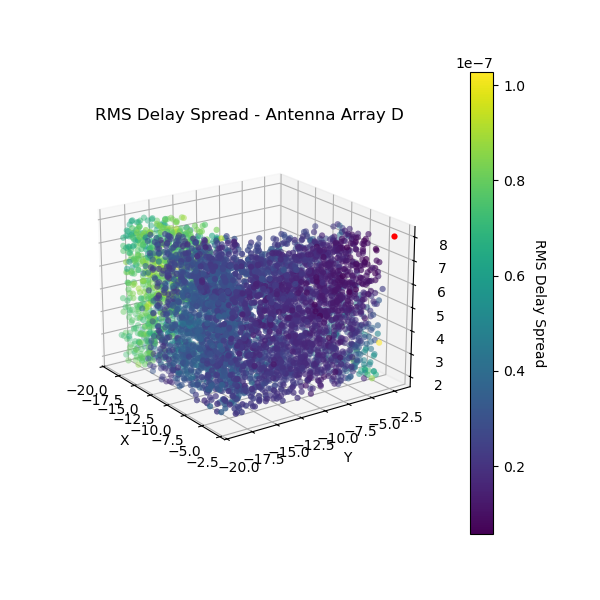

In [6]:
%matplotlib widget

array = 3

# Plot datapoints
ax = plt.figure(figsize=(6,6)).add_subplot(projection='3d')
ax.set_title("RMS Delay Spread - Antenna Array " + chr(ord("A") + array))
sc = ax.scatter(groundtruth_positions[:, 0], groundtruth_positions[:, 1], groundtruth_positions[:, 2], c = delayspreads_by_array[:, array], linewidths = 0)

ax.scatter(array_positions[array, 0], array_positions[array, 1], array_positions[array, 2], c = 'red', linewidths = 0)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Customize the view angle so it's easier to see that the scatter points lie
# on the plane y=0
ax.view_init(elev=20., azim=-35, roll=0)

# Add the colorbar, linked to the 'sc' object
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label('RMS Delay Spread', rotation=270, labelpad=15)

plt.show()